# Classical Pipeline — Reply Transit Anomaly Detection

This notebook implements the classical pipeline end-to-end: raw data ingestion, preprocessing, feature engineering, baseline construction, anomaly detection, post-processing and ranked report generation.

The output is a transit anomaly report ranking the most suspicious observations by an operational risk score, used in the comparative analysis against the multi-agent system.

We track total execution time from the first cell to the last to compare the two pipelines.

## Setup — Imports, Configuration and Constants

All imports, paths and reusable constants are defined here once. The pipeline below uses these throughout without redeclaring them.

In [ ]:
# Imports
import json
import time
import warnings
from pathlib import Path
import tabulate

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

warnings.filterwarnings("ignore")

# Master timer — covers the full pipeline
PIPELINE_START = time.time()

In [48]:
# Paths
BASE_DIR = Path.cwd()
IO_DIR = BASE_DIR / "io"
PREPROCESS_DIR = IO_DIR / "preprocessing"
FEAT_ENGEERING_DIR = IO_DIR / "feat_engineering"
ANOMALY_DIR = IO_DIR / "anomaly_detection"
REPORT_DIR = IO_DIR / "classical_report"
IMAGES_DIR = REPORT_DIR / "images"

for d in [IO_DIR, PREPROCESS_DIR, FEAT_ENGEERING_DIR, ANOMALY_DIR, REPORT_DIR, IMAGES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CASES_DATA = IO_DIR / "ALLARMI.csv"
PASSENGERS_DATA = IO_DIR / "TIPOLOGIA_VIAGGIATORE.csv"
CASES_CLEAN_OUT = PREPROCESS_DIR / "cases_clean.csv"
PASSENGERS_CLEAN_OUT = PREPROCESS_DIR / "passenger_clean.csv"
FEAT_ENGEERING_OUT = FEAT_ENGEERING_DIR / "feat_engineered.csv"

# Column translations
COLUMN_MAPPING_PASSENGERS = {
    'AREOPORTO_ARRIVO': 'arrival_airport_code',
    'AREOPORTO_PARTENZA': 'departure_airport_code',
    'DATA_PARTENZA': 'departure_date',
    'DESCR_AEREOPORTO_ARR': 'arrival_airport_name',
    'DESCR_AEREOPORTO_PART': 'departure_airport_name',
    'CITTA_ARR': 'arrival_city',
    'CITTA_PARTENZA': 'departure_city',
    'CODICE_PAESE_ARR': 'arrival_country_code',
    'CODICE_PAESE_PART': 'departure_country_code',
    'PAESE_ARR': 'arrival_country',
    'PAESE_PART': 'departure_country',
    'ZONA': 'zone',
    'ENTRATI': 'passengers_entries_count',
    'INVESTIGATI': 'passengers_investigated_count',
    'ALLARMATI': 'passengers_flagged_count',
    'GENERE': 'gender',
    'FLAG_TRANSITO': 'transit_flag',
    'ESITO_CONTROLLO': 'control_result',
    'Tipo Documento': 'document_type',
    'FASCIA ETA': 'age_range',
    '3nazionalita': 'nationality',
    'compagnia%aerea': 'airline',
    'num volo': 'flight_number'
}

COLUMN_MAPPING_CASES = {
    'OCCORRENZE': 'event_type',
    'AREOPORTO_ARRIVO': 'arrival_airport_code',
    'AREOPORTO_PARTENZA': 'departure_airport_code',
    'DATA_PARTENZA': 'departure_date',
    'DESCR_AEREOPORTO_ARR': 'arrival_airport_name',
    'DESCR_AEREOPORTO_PART': 'departure_airport_name',
    'CITTA_ARR': 'arrival_city_name',
    'CITTA_PARTENZA': 'departure_city_name',
    'CODICE PAESE ARR': 'arrival_country_code',
    'CODICE_PAESE_PART': 'departure_country_code',
    'MOTIVO_ALLARME': 'alarm_reason',
    'paese%arr': 'arrival_country_name',
    'Paese Partenza': 'departure_country_name',
    'tot voli': 'total_flights',
    '3zona': 'region_zone'
}

GENDER_MAPPING = {
    'F': 'F', 'f': 'F', 'Femmina': 'F', 'Female': 'F', 'FEMALE': 'F', '2': 'F',
    'M': 'M', 'm': 'M', 'Maschio': 'M', 'Male': 'M', 'MALE': 'M', '1': 'M',
    'X': 'Other/NB', 'N/B': 'Other/NB'
}

COUNTRY_CODES = {'GB': 'GBR', 'EG': 'EGY', 'TR': 'TUR', 'AL': 'ALB', 'MA': 'MAR', 'AE': 'ARE'}

# Feature groups
ID_COLS = ["date", "route_city", "route_country", "route_airport"]
CALENDAR_COLS = ["year", "month", "day", "weekday", "is_weekend"]
BASE_COLS = ["entries", "investigated", "flagged", "investigation_rate", "flag_rate", "flag_given_investigated"]
SEGMENT_COLS = [
    "nationality_count", "avg_nat_entries", "max_nat_entries", "avg_nat_flag_rate", "max_nat_flag_rate",
    "document_type_count", "avg_doc_entries", "max_doc_entries", "avg_doc_flag_rate", "max_doc_flag_rate",
    "airline_count", "avg_airline_entries", "max_airline_entries", "avg_airline_flag_rate", "max_airline_flag_rate",
    "control_result_count", "avg_control_entries", "max_control_entries", "avg_control_flag_rate", "max_control_flag_rate"
]
CASE_COLS = ["has_case_match", "case_records", "total_flights", "unique_alarm_reasons", "unique_event_types", "alarm_density_per_entry"]
CHANGE_COLS = ['entries_lag1', 'entries_diff1', 'entries_pct_change1',
               'investigated_lag1', 'investigated_diff1', 'investigated_pct_change1',
               'flagged_lag1', 'flagged_diff1',
               'investigation_rate_lag1', 'investigation_rate_diff1', 'investigation_rate_pct_change1',
               'flag_rate_lag1', 'flag_rate_diff1']
VOLUME_FLAG_COLS = ["is_low_volume", "is_low_volume_50"]

# 1. Preprocessing

The two raw datasets contain inconsistent column names, mixed date formats, placeholder values and broken numeric fields. This section cleans them and harmonizes the schema.

## 1.1 Passengers Dataset (TIPOLOGIA_VIAGGIATORE)

In [49]:
df_passengers = pd.read_csv(PASSENGERS_DATA)
df_passengers.head()

,NAZIONALITA,AREOPORTO_ARRIVO,AREOPORTO_PARTENZA,ANNO_PARTENZA,MESE_PARTENZA,GIORNO_PARTENZA,DATA_PARTENZA,DESCR_AEREOPORTO_ARR,DESCR_AEREOPORTO_PART,CITTA_ARR,...,COMPAGNIA_AEREA,NUMERO_VOLO,ESITO_CONTROLLO,note_operatore,codice_rischio,Tipo Documento,FASCIA ETA,3nazionalita,compagnia%aerea,num volo
0,ALB,NAP,DUR,2024,02,13,2024-02-13 07:30:00,Napoli Capodichino,King Shaka International,Napoli,...,Fly Dubai,FZ1681,RESPINTO,NaN,NaN,Passaporto,N.D.,ALB,Fly Dubai,FZ1681
1,NaN,FCO,JFK,2024,01,22,2024-01-22 16:35:00,Fiumicino,John F Kennedy International,Roma,...,ITA Airways,AZ0609,NaN,NaN,NaN,Carta d'identità,18-30,ALB,ITA Airways,AZ0609
2,ALB,TSF,TIA,2024,02,4,2024-02-04 20:10:00,Treviso-Sant'Angelo,Rinas Mother Teresa,Treviso,...,Ryanair DAC,FR8400,SEGNALATO,NaN,NaN,N.D.,31-45,ALB,Ryanair DAC,FR8400
3,AFG,FCO,IST,2024,01,25,2024-01-25 13:05:00,Fiumicino,Havalimani,Roma,...,Turkish Airlines,TK1865,NaN,NaN,NaN,N.D.,61+,AFG,Turkish Airlines,TK1865
4,ALB,BGY,MLE,2024,02,13,FEB 13 2024,Orio al Serio,Male International,Bergamo,...,Fly Dubai,FZ1571,SEGNALATO,NaN,NaN,Permesso di soggiorno,46-60,ALB,Fly Dubai,FZ1571


In [50]:
display(df_passengers.columns, df_passengers.shape)
df_passengers.isnull().sum().sort_values(ascending=False)

Index(['NAZIONALITA', 'AREOPORTO_ARRIVO', 'AREOPORTO_PARTENZA',
       'ANNO_PARTENZA', 'MESE_PARTENZA', 'GIORNO_PARTENZA', 'DATA_PARTENZA',
       'DESCR_AEREOPORTO_ARR', 'DESCR_AEREOPORTO_PART', 'CITTA_ARR',
       'CITTA_PARTENZA', 'CODICE_PAESE_ARR', 'CODICE_PAESE_PART', 'PAESE_ARR',
       'PAESE_PART', 'ZONA', 'ENTRATI', 'INVESTIGATI', 'ALLARMATI',
       'TIPO_DOCUMENTO', 'GENERE', 'FASCIA_ETA', 'FLAG_TRANSITO',
       'COMPAGNIA_AEREA', 'NUMERO_VOLO', 'ESITO_CONTROLLO', 'note_operatore',
       'codice_rischio', 'Tipo Documento', 'FASCIA ETA', '3nazionalita',
       'compagnia%aerea', 'num volo'],
      dtype='str')

(5095, 33)

codice_rischio           5054
note_operatore           5034
ESITO_CONTROLLO          1289
NAZIONALITA               116
COMPAGNIA_AEREA            87
NUMERO_VOLO                70
TIPO_DOCUMENTO             62
GENERE                     45
AREOPORTO_ARRIVO            0
CITTA_ARR                   0
AREOPORTO_PARTENZA          0
ANNO_PARTENZA               0
MESE_PARTENZA               0
GIORNO_PARTENZA             0
DATA_PARTENZA               0
DESCR_AEREOPORTO_ARR        0
DESCR_AEREOPORTO_PART       0
ENTRATI                     0
ZONA                        0
PAESE_PART                  0
PAESE_ARR                   0
CODICE_PAESE_PART           0
CODICE_PAESE_ARR            0
CITTA_PARTENZA              0
INVESTIGATI                 0
FASCIA_ETA                  0
FLAG_TRANSITO               0
ALLARMATI                   0
Tipo Documento              0
FASCIA ETA                  0
3nazionalita                0
compagnia%aerea             0
num volo                    0
dtype: int

Five columns are duplicated or carry inconsistent data and are dropped. Placeholder values are replaced with `UNKNOWN`. The logical constraint `ENTRATI ≥ INVESTIGATI ≥ ALLARMATI` is enforced.

In [51]:
# Drop columns with too many inconsistencies
to_be_dropped = ['FASCIA_ETA', 'TIPO_DOCUMENTO', 'NAZIONALITA', 'NUMERO_VOLO', 'COMPAGNIA_AEREA',
                 'ANNO_PARTENZA', 'MESE_PARTENZA', 'GIORNO_PARTENZA', 'note_operatore', 'codice_rischio']
df_passengers.drop(columns=to_be_dropped, errors='ignore', inplace=True)

# Standardize gender
df_passengers['GENERE'] = df_passengers['GENERE'].map(GENDER_MAPPING).fillna('UNKNOWN')

# Clean numeric passenger counts
for col in ['ENTRATI', 'INVESTIGATI', 'ALLARMATI']:
    df_passengers[col] = (df_passengers[col].astype(str)
                          .str.replace('pax', '', case=False)
                          .str.replace('~', '')
                          .str.replace(',', '.'))
    df_passengers[col] = pd.to_numeric(df_passengers[col], errors='coerce').astype('Int64')

# Drop rows where both core metrics are missing
df_passengers = df_passengers.dropna(subset=['ENTRATI', 'INVESTIGATI'], how='all').copy()

# Handle negatives and recover missing values via the logical chain
for col in ['INVESTIGATI', 'ALLARMATI', 'ENTRATI']:
    df_passengers.loc[df_passengers[col] < 0, col] = 0

df_passengers['ALLARMATI'].fillna(0, inplace=True)
df_passengers['INVESTIGATI'] = df_passengers['INVESTIGATI'].fillna(df_passengers['ALLARMATI'])
df_passengers['ENTRATI'] = df_passengers['ENTRATI'].fillna(df_passengers['INVESTIGATI'])

# Enforce ENTRATI >= INVESTIGATI >= ALLARMATI and a realistic upper bound
valid_rows = ((df_passengers['ALLARMATI'] <= df_passengers['INVESTIGATI']) &
              (df_passengers['INVESTIGATI'] <= df_passengers['ENTRATI']) &
              (df_passengers['ENTRATI'] <= 853))
df_passengers = df_passengers[valid_rows].copy()

Departure dates use mixed formats and need to be standardized.

In [52]:
df_passengers['DATA_PARTENZA'] = df_passengers['DATA_PARTENZA'].str.upper().str.replace('GEN', 'JAN')
df_passengers['DATA_PARTENZA'] = pd.to_datetime(df_passengers['DATA_PARTENZA'], format='mixed', dayfirst=True)

Country codes are converted to 3-letter ISO format. Text columns are uppercased for consistency, and column names are translated to English.

In [53]:
# Replace placeholders
placeholders = ['N.D.', 'n.d.', 'N/A', ' ', '?', '//']
df_passengers = df_passengers.replace(placeholders, 'UNKNOWN')
df_passengers['ESITO_CONTROLLO'] = df_passengers['ESITO_CONTROLLO'].fillna('UNKNOWN')
df_passengers = df_passengers.drop_duplicates()

# ISO country codes
df_passengers['CODICE_PAESE_ARR'] = df_passengers['CODICE_PAESE_ARR'].replace('IT', 'ITA')
df_passengers['CODICE_PAESE_PART'].replace(COUNTRY_CODES, inplace=True)

# Uppercase text columns
for col in ['AREOPORTO_ARRIVO', 'AREOPORTO_PARTENZA', 'CITTA_ARR', 'CITTA_PARTENZA',
            'PAESE_ARR', 'PAESE_PART', 'DESCR_AEREOPORTO_ARR', 'DESCR_AEREOPORTO_PART']:
    df_passengers[col] = df_passengers[col].str.upper()

# Translate column names
df_passengers.rename(columns=COLUMN_MAPPING_PASSENGERS, inplace=True)
df_passengers.head()

,arrival_airport_code,departure_airport_code,departure_date,arrival_airport_name,departure_airport_name,arrival_city,departure_city,arrival_country_code,departure_country_code,arrival_country,...,passengers_investigated_count,passengers_flagged_count,gender,transit_flag,control_result,document_type,age_range,nationality,airline,flight_number
0,NAP,DUR,2024-02-13 07:30:00,NAPOLI CAPODICHINO,KING SHAKA INTERNATIONAL,NAPOLI,DURBAN,ITA,ZAF,ITALIA,...,1,0,F,Singola Tratta,RESPINTO,Passaporto,UNKNOWN,ALB,Fly Dubai,FZ1681
2,TSF,TIA,2024-04-02 20:10:00,TREVISO-SANT'ANGELO,RINAS MOTHER TERESA,TREVISO,TIRANA,ITA,ALB,ITALIA,...,58,13,F,Singola Tratta,SEGNALATO,UNKNOWN,31-45,ALB,Ryanair DAC,FR8400
3,FCO,IST,2024-01-25 13:05:00,FIUMICINO,HAVALIMANI,ROMA,ISTANBUL,ITA,TR,ITALIA,...,1,0,M,Singola Tratta,UNKNOWN,UNKNOWN,61+,AFG,Turkish Airlines,TK1865
4,BGY,MLE,2024-02-13 00:00:00,ORIO AL SERIO,MALE INTERNATIONAL,BERGAMO,MALE,ITA,MDV,ITALIA,...,2,1,F,Singola Tratta,SEGNALATO,Permesso di soggiorno,46-60,ALB,Fly Dubai,FZ1571
5,TSF,LTN,2024-02-18 16:30:00,TREVISO-SANT'ANGELO,LONDON LUTON,TREVISO,LONDRA,ITA,GBR,ITALIA,...,3,0,F,Singola Tratta,RESPINTO,Carta d'identità,18-30,ALB,Ryanair DAC,FR1050


## 1.2 Cases Dataset (ALLARMI)

In [54]:
df_cases = pd.read_csv(CASES_DATA)
display(df_cases.head())
display(df_cases.columns)
df_cases.shape

,OCCORRENZE,AREOPORTO_ARRIVO,AREOPORTO_PARTENZA,ANNO_PARTENZA,MESE_PARTENZA,DATA_PARTENZA,DESCR_AEREOPORTO_ARR,DESCR_AEREOPORTO_PART,CITTA_ARR,CITTA_PARTENZA,...,ZONA,TOT,MOTIVO_ALLARME,note_operatore,flag_rischio,Paese Partenza,CODICE PAESE ARR,3zona,paese%arr,tot voli
0,Voli con Allarmi,FCO,IST,2024,01,2024-01-30 09:15:00,Fiumicino,Havalimani,Roma,Istanbul,...,5,1,Manuale,NaN,NaN,Turchia,ITA,5,Italia,1
1,Viaggiatori con Allarmi,CIA,STN,2024,02,2024-02-03 13:15:00,Ciampino,Stansted,Roma,Londra,...,5,5,Manuale,NaN,NaN,Regno Unito,ITA,5,Italia,5
2,Viaggiatori entrati nel Sistema,FCO,LHR,2024,01,2024-01-15 08:45:00,Fiumicino,London Heathrow,Roma,Londra,...,5,110,TSC,NaN,NaN,Regno Unito,ITA,5,Italia,110
3,Voli con Allarmi,MXP,LHR,2024,02,2024-02-02 08:40:00,Malpensa,London Heathrow,Milano,Londra,...,2,1,SDI,NaN,NaN,Regno Unito,ITA,2,Italia,1
4,Viaggiatori con Allarmi,PSA,BRS,2024,02,2024-02-16 12:50:00,Galileo Galilei,Bristol,Pisa,Bristol,...,8,2,INTERPOL,NaN,NaN,Regno Unito,ITA,8,Italia,2


Index(['OCCORRENZE', 'AREOPORTO_ARRIVO', 'AREOPORTO_PARTENZA', 'ANNO_PARTENZA',
       'MESE_PARTENZA', 'DATA_PARTENZA', 'DESCR_AEREOPORTO_ARR',
       'DESCR_AEREOPORTO_PART', 'CITTA_ARR', 'CITTA_PARTENZA',
       'CODICE_PAESE_ARR', 'CODICE_PAESE_PART', 'PAESE_ARR', 'PAESE_PART',
       'ZONA', 'TOT', 'MOTIVO_ALLARME', 'note_operatore', 'flag_rischio',
       'Paese Partenza', 'CODICE PAESE ARR', '3zona', 'paese%arr', 'tot voli'],
      dtype='str')

(5080, 24)

Inconsistent or redundant columns are dropped, then placeholders, dates and uppercase formatting are handled in one pass.

In [55]:
columns_to_be_dropped = ['PAESE_ARR', 'PAESE_PART', 'ZONA', 'note_operatore', 'flag_rischio',
                         'ANNO_PARTENZA', 'MESE_PARTENZA', 'TOT', 'CODICE_PAESE_ARR']
df_cases.drop(columns=columns_to_be_dropped, errors='ignore', inplace=True)

df_cases = df_cases.drop_duplicates()
df_cases['tot voli'] = df_cases['tot voli'].astype(str).str.extract(r'(\d+)').astype(float).fillna(0).astype(int)

# Date standardization
df_cases['DATA_PARTENZA'] = df_cases['DATA_PARTENZA'].astype(str).str.upper().str.replace('GEN', 'JAN')
df_cases['DATA_PARTENZA'] = pd.to_datetime(df_cases['DATA_PARTENZA'], format='mixed', dayfirst=True, errors='coerce')

# Uppercase text columns
for col in ['AREOPORTO_ARRIVO', 'AREOPORTO_PARTENZA', 'DESCR_AEREOPORTO_ARR', 'DESCR_AEREOPORTO_PART']:
    df_cases[col] = df_cases[col].str.upper()

# Replace placeholders in OCCORRENZE
df_cases['OCCORRENZE'] = df_cases['OCCORRENZE'].replace(['???', 'N/C', 'Altro'], 'UNKNOWN')

# Departure airport name fallback
placeholders = [' ', '?', 'N.D.', 'ND', '-', '//', 'N/A ', '  ', '- ', 'N/A', '', 'NULL']
df_cases['DESCR_AEREOPORTO_PART'] = df_cases['DESCR_AEREOPORTO_PART'].str.upper().str.strip()
df_cases['DESCR_AEREOPORTO_PART'] = df_cases['DESCR_AEREOPORTO_PART'].replace(placeholders, np.nan)
df_cases['DESCR_AEREOPORTO_PART'] = df_cases['DESCR_AEREOPORTO_PART'].fillna(df_cases['AREOPORTO_PARTENZA'])

# Departure country code fallback
placeholders_cc = ['n.d.', 'ND', '?', 'unknown', 'EU', 'XX', '00', '//', '-', 'ZZ', ' ']
df_cases['CODICE_PAESE_PART'] = df_cases['CODICE_PAESE_PART'].replace(COUNTRY_CODES)
df_cases['CODICE_PAESE_PART'] = df_cases['CODICE_PAESE_PART'].replace(placeholders_cc, 'UNKNOWN')
df_cases['CODICE_PAESE_PART'].fillna('UNKNOWN', inplace=True)
df_cases['CODICE_PAESE_PART'] = df_cases['CODICE_PAESE_PART'].str.upper()

reference_map = (df_cases[df_cases['CODICE_PAESE_PART'] != 'UNKNOWN']
                 .set_index('Paese Partenza')['CODICE_PAESE_PART'].to_dict())
df_cases.loc[df_cases['CODICE_PAESE_PART'] == 'UNKNOWN', 'CODICE_PAESE_PART'] = (
    df_cases['Paese Partenza'].map(reference_map))

# Departure city
df_cases['CITTA_PARTENZA'].fillna('unknown', inplace=True)
df_cases['CITTA_PARTENZA'] = df_cases.apply(
    lambda row: f"UNKNOWN ({row['Paese Partenza']})" if row['CITTA_PARTENZA'] in placeholders_cc else row['CITTA_PARTENZA'],
    axis=1)

# Final uppercase pass
for col in ['Paese Partenza', 'CITTA_ARR', 'CITTA_PARTENZA', 'paese%arr', 'MOTIVO_ALLARME']:
    df_cases[col] = df_cases[col].str.upper()
df_cases['MOTIVO_ALLARME'].fillna('UNKNOWN', inplace=True)

0        MANUALE
1        MANUALE
2            TSC
3            SDI
4       INTERPOL
          ...   
5075         TSC
5076         TSC
5077        NSIS
5078         TSC
5079         TSC
Name: MOTIVO_ALLARME, Length: 5030, dtype: str

A country must map to a single region — we enforce this via the modal mapping.

In [56]:
country_zone_map = df_cases.groupby('CODICE_PAESE_PART')['3zona'].agg(lambda x: x.mode().iloc[0]).to_dict()
df_cases['3zona'] = df_cases['CODICE_PAESE_PART'].map(country_zone_map)

In [57]:
df_cases.rename(columns=COLUMN_MAPPING_CASES, inplace=True)
df_cases.head()

,event_type,arrival_airport_code,departure_airport_code,departure_date,arrival_airport_name,departure_airport_name,arrival_city_name,departure_city_name,departure_country_code,alarm_reason,departure_country_name,arrival_country_code,region_zone,arrival_country_name,total_flights
0,Voli con Allarmi,FCO,IST,2024-01-30 09:15:00,FIUMICINO,HAVALIMANI,ROMA,ISTANBUL,TUR,MANUALE,TURCHIA,ITA,5.0,ITALIA,1
1,Viaggiatori con Allarmi,CIA,STN,2024-03-02 13:15:00,CIAMPINO,STANSTED,ROMA,LONDRA,GBR,MANUALE,REGNO UNITO,ITA,2.0,ITALIA,5
2,Viaggiatori entrati nel Sistema,FCO,LHR,2024-01-15 08:45:00,FIUMICINO,LONDON HEATHROW,ROMA,LONDRA,GBR,TSC,REGNO UNITO,ITA,2.0,ITALIA,110
3,Voli con Allarmi,MXP,LHR,2024-02-02 08:40:00,MALPENSA,LONDON HEATHROW,MILANO,LONDRA,GBR,SDI,REGNO UNITO,ITA,2.0,ITALIA,1
4,Viaggiatori con Allarmi,PSA,BRS,2024-02-16 12:50:00,GALILEO GALILEI,BRISTOL,PISA,BRISTOL,GBR,INTERPOL,REGNO UNITO,ITA,2.0,ITALIA,2


Cleaned datasets are saved.

In [58]:
df_cases.to_csv(CASES_CLEAN_OUT, index=False)
df_passengers.to_csv(PASSENGERS_CLEAN_OUT, index=False)

# 2. Feature Engineering

We build a daily route table aggregated at `date × route_airport`. This grain is unique, aligns with operational behavior and gives the most precise level for anomaly detection. `route_city` and `route_country` are kept for interpretability.

In [59]:
passenger = df_passengers.copy()
cases = df_cases.copy()

## 2.1 Calendar and Route Features

In [60]:
passenger["departure_date"] = pd.to_datetime(passenger["departure_date"], errors="coerce")
cases["departure_date"] = pd.to_datetime(cases["departure_date"], errors="coerce")

for df_ in [passenger, cases]:
    df_["year"] = df_["departure_date"].dt.year
    df_["month"] = df_["departure_date"].dt.month
    df_["day"] = df_["departure_date"].dt.day
    df_["hour"] = df_["departure_date"].dt.hour
    df_["weekday"] = df_["departure_date"].dt.dayofweek
    df_["is_weekend"] = df_["weekday"].isin([5, 6]).astype(int)
    df_["date"] = df_["departure_date"].dt.floor("D")

passenger["document_type"] = passenger["document_type"].fillna("UNKNOWN")
cases["alarm_reason"] = cases["alarm_reason"].fillna("UNKNOWN")

passenger["route_country"] = passenger["departure_country_code"].astype(str) + "_" + passenger["arrival_country_code"].astype(str)
passenger["route_city"] = passenger["departure_city"].astype(str) + "_" + passenger["arrival_city"].astype(str)
passenger["route_airport"] = passenger["departure_airport_code"].astype(str) + "_" + passenger["arrival_airport_code"].astype(str)

cases["route_country"] = cases["departure_country_code"].astype(str) + "_" + cases["arrival_country_code"].astype(str)
cases["route_city"] = cases["departure_city_name"].astype(str) + "_" + cases["arrival_city_name"].astype(str)
cases["route_airport"] = cases["departure_airport_code"].astype(str) + "_" + cases["arrival_airport_code"].astype(str)

## 2.2 Ratio Features

Investigation rate, flag rate and conditional flag rate are computed at the row level. A low-volume flag is added because many rows have very few entries (so we filter without dropping).

In [61]:
passenger["is_low_volume"] = (passenger["passengers_entries_count"] < 10).astype(int)

passenger["investigation_rate"] = np.where(
    passenger["passengers_entries_count"] > 0,
    passenger["passengers_investigated_count"] / passenger["passengers_entries_count"], np.nan)
passenger["flag_rate"] = np.where(
    passenger["passengers_entries_count"] > 0,
    passenger["passengers_flagged_count"] / passenger["passengers_entries_count"], np.nan)
passenger["flag_given_investigated"] = np.where(
    passenger["passengers_investigated_count"] > 0,
    passenger["passengers_flagged_count"] / passenger["passengers_investigated_count"], np.nan)

## 2.3 Base Daily Route Table

In [62]:
route_daily = (passenger.groupby(["date", "route_airport"], as_index=False)
    .agg(route_city=("route_city", "first"),
         route_country=("route_country", "first"),
         entries=("passengers_entries_count", "sum"),
         investigated=("passengers_investigated_count", "sum"),
         flagged=("passengers_flagged_count", "sum")))

route_daily["investigation_rate"] = np.where(route_daily["entries"] > 0, route_daily["investigated"] / route_daily["entries"], np.nan)
route_daily["flag_rate"] = np.where(route_daily["entries"] > 0, route_daily["flagged"] / route_daily["entries"], np.nan)
route_daily["flag_given_investigated"] = np.where(route_daily["investigated"] > 0, route_daily["flagged"] / route_daily["investigated"], np.nan)

route_daily["year"] = route_daily["date"].dt.year
route_daily["month"] = route_daily["date"].dt.month
route_daily["day"] = route_daily["date"].dt.day
route_daily["weekday"] = route_daily["date"].dt.dayofweek
route_daily["is_weekend"] = route_daily["weekday"].isin([5, 6]).astype(int)

route_daily.head()

,date,route_airport,route_city,route_country,entries,investigated,flagged,investigation_rate,flag_rate,flag_given_investigated,year,month,day,weekday,is_weekend
0,2023-12-31,JFK_FCO,NEW YORK_ROMA,USA_ITA,3,3,0,1.0,0.0,0.0,2023,12,31,6,1
1,2024-01-01,ADB_MXP,SMIRNE_MILANO,TUR_ITA,1,1,0,1.0,0.0,0.0,2024,1,1,0,0
2,2024-01-01,AMM_FCO,AMMAN_ROMA,JOR_ITA,2,0,0,0.0,0.0,NaN,2024,1,1,0,0
3,2024-01-01,BEG_BGY,BELGRADO_BERGAMO,SRB_ITA,1,1,0,1.0,0.0,0.0,2024,1,1,0,0
4,2024-01-01,BFS_BGY,BELFAST_BERGAMO,GBR_ITA,1,1,0,1.0,0.0,0.0,2024,1,1,0,0


## 2.4 Segment-Level Features

For each route-day, we aggregate by nationality, document type, airline and control result. Per segment we compute count (diversity), average and maximum entries, and average/maximum flag rate.

In [63]:
# Nationality
route_nat_daily = (passenger.groupby(["date", "route_airport", "nationality"], as_index=False)
    .agg(nat_entries=("passengers_entries_count", "sum"),
         nat_investigated=("passengers_investigated_count", "sum"),
         nat_flagged=("passengers_flagged_count", "sum")))
route_nat_daily["nat_flag_rate"] = np.where(route_nat_daily["nat_entries"] > 0,
    route_nat_daily["nat_flagged"] / route_nat_daily["nat_entries"], np.nan)

nat_features = (route_nat_daily.groupby(["date", "route_airport"], as_index=False)
    .agg(nationality_count=("nationality", "nunique"),
         avg_nat_entries=("nat_entries", "mean"),
         max_nat_entries=("nat_entries", "max"),
         avg_nat_flag_rate=("nat_flag_rate", "mean"),
         max_nat_flag_rate=("nat_flag_rate", "max")))
route_daily = route_daily.merge(nat_features, on=["date", "route_airport"], how="left")

# Document type
route_doc_daily = (passenger.groupby(["date", "route_airport", "document_type"], as_index=False)
    .agg(doc_entries=("passengers_entries_count", "sum"),
         doc_flagged=("passengers_flagged_count", "sum")))
route_doc_daily["doc_flag_rate"] = np.where(route_doc_daily["doc_entries"] > 0,
    route_doc_daily["doc_flagged"] / route_doc_daily["doc_entries"], np.nan)

doc_features = (route_doc_daily.groupby(["date", "route_airport"], as_index=False)
    .agg(document_type_count=("document_type", "nunique"),
         avg_doc_entries=("doc_entries", "mean"),
         max_doc_entries=("doc_entries", "max"),
         avg_doc_flag_rate=("doc_flag_rate", "mean"),
         max_doc_flag_rate=("doc_flag_rate", "max")))
route_daily = route_daily.merge(doc_features, on=["date", "route_airport"], how="left")

# Airline
route_airline_daily = (passenger.groupby(["date", "route_airport", "airline"], as_index=False)
    .agg(airline_entries=("passengers_entries_count", "sum"),
         airline_flagged=("passengers_flagged_count", "sum")))
route_airline_daily["airline_flag_rate"] = np.where(route_airline_daily["airline_entries"] > 0,
    route_airline_daily["airline_flagged"] / route_airline_daily["airline_entries"], np.nan)

airline_features = (route_airline_daily.groupby(["date", "route_airport"], as_index=False)
    .agg(airline_count=("airline", "nunique"),
         avg_airline_entries=("airline_entries", "mean"),
         max_airline_entries=("airline_entries", "max"),
         avg_airline_flag_rate=("airline_flag_rate", "mean"),
         max_airline_flag_rate=("airline_flag_rate", "max")))
route_daily = route_daily.merge(airline_features, on=["date", "route_airport"], how="left")

# Control result
route_control_daily = (passenger.groupby(["date", "route_airport", "control_result"], dropna=False, as_index=False)
    .agg(control_entries=("passengers_entries_count", "sum"),
         control_flagged=("passengers_flagged_count", "sum")))
route_control_daily["control_flag_rate"] = np.where(route_control_daily["control_entries"] > 0,
    route_control_daily["control_flagged"] / route_control_daily["control_entries"], np.nan)

control_features = (route_control_daily.groupby(["date", "route_airport"], as_index=False)
    .agg(control_result_count=("control_result", "nunique"),
         avg_control_entries=("control_entries", "mean"),
         max_control_entries=("control_entries", "max"),
         avg_control_flag_rate=("control_flag_rate", "mean"),
         max_control_flag_rate=("control_flag_rate", "max")))
route_daily = route_daily.merge(control_features, on=["date", "route_airport"], how="left")

## 2.5 Case Features

Cases data is aggregated per route-day and merged into the main table. `has_case_match` is set before fillna so we preserve the information that some routes have no matched alarm cases.

In [64]:
cases_route_daily = (cases.groupby(["date", "route_airport"], as_index=False)
    .agg(case_records=("event_type", "size"),
         total_flights=("total_flights", "sum"),
         unique_alarm_reasons=("alarm_reason", "nunique"),
         unique_event_types=("event_type", "nunique")))

route_daily = route_daily.merge(cases_route_daily, on=["date", "route_airport"], how="left")
route_daily["has_case_match"] = route_daily["case_records"].notna().astype(int)
route_daily["alarm_density_per_entry"] = np.where(route_daily["entries"] > 0,
    route_daily["case_records"] / route_daily["entries"], np.nan)

route_daily = route_daily.sort_values(["route_airport", "date"]).reset_index(drop=True)

## 2.6 Temporal Change Features

For each route, we compute lag-1, absolute difference and percentage change of entries, investigations, flags and rates. These capture day-to-day shifts in operational behavior.

In [65]:
change_cols = ["entries", "investigated", "flagged", "investigation_rate", "flag_rate"]

for col in change_cols:
    route_daily[f"{col}_lag1"] = route_daily.groupby("route_airport")[col].shift(1)
    route_daily[f"{col}_diff1"] = route_daily[col] - route_daily[f"{col}_lag1"]
    route_daily[f"{col}_pct_change1"] = np.where(
        route_daily[f"{col}_lag1"].notna() & (route_daily[f"{col}_lag1"] != 0),
        (route_daily[col] - route_daily[f"{col}_lag1"]) / route_daily[f"{col}_lag1"], np.nan)

## 2.7 Quick Sanity Checks

We plot the top 3 routes by traffic to make sure the temporal patterns and rate columns look reasonable.

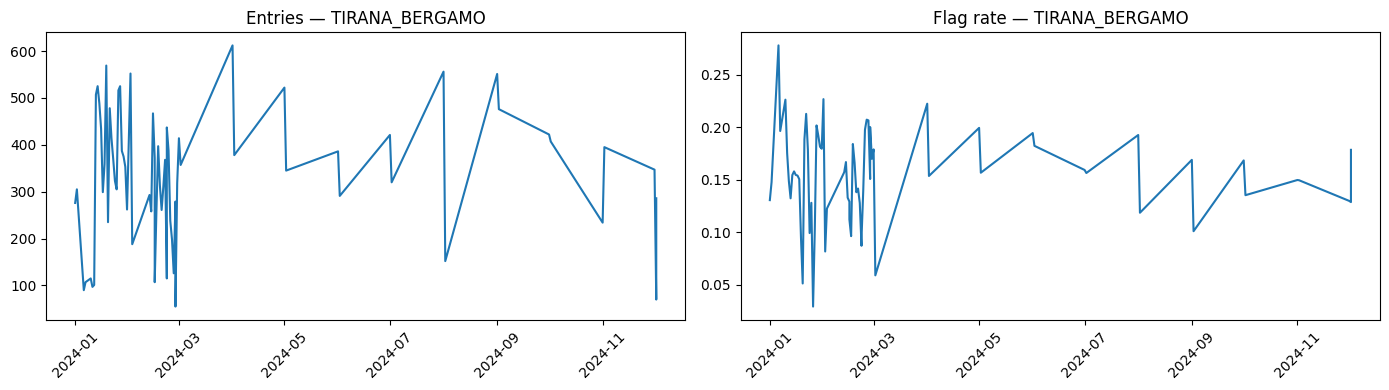

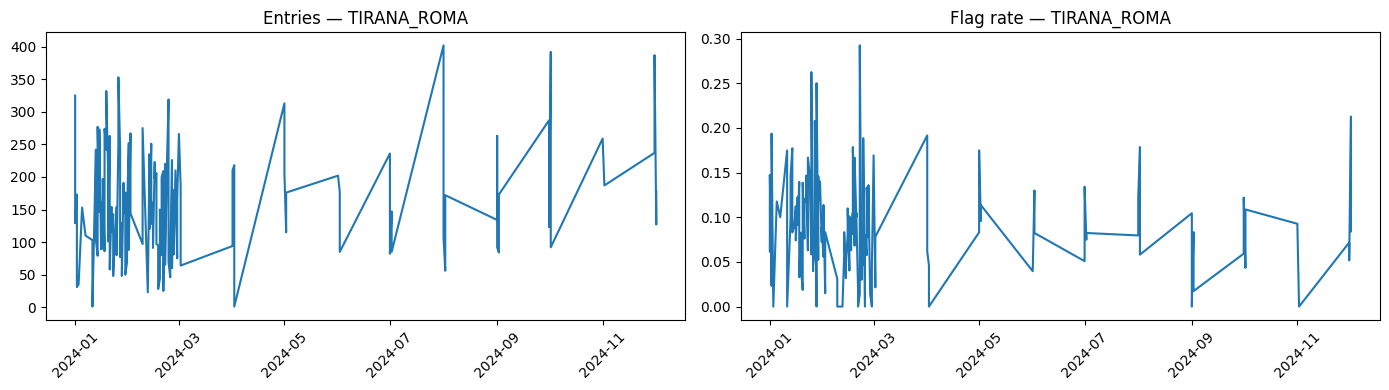

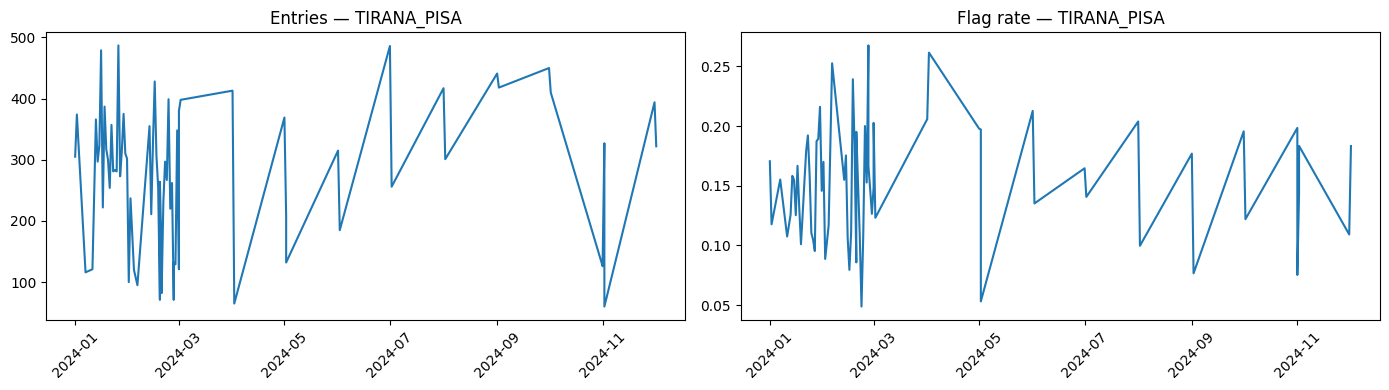

In [66]:
top_routes = route_daily.groupby("route_city")["entries"].sum().sort_values(ascending=False).head(3).index.tolist()

for route in top_routes:
    tmp = route_daily[route_daily["route_city"] == route].sort_values("date")
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
    axes[0].plot(tmp["date"], tmp["entries"])
    axes[0].set_title(f"Entries — {route}")
    axes[1].plot(tmp["date"], tmp["flag_rate"])
    axes[1].set_title(f"Flag rate — {route}")
    for ax in axes:
        ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

Most routes have very few entries — we keep low-volume rows but flag them so they can be filtered downstream.

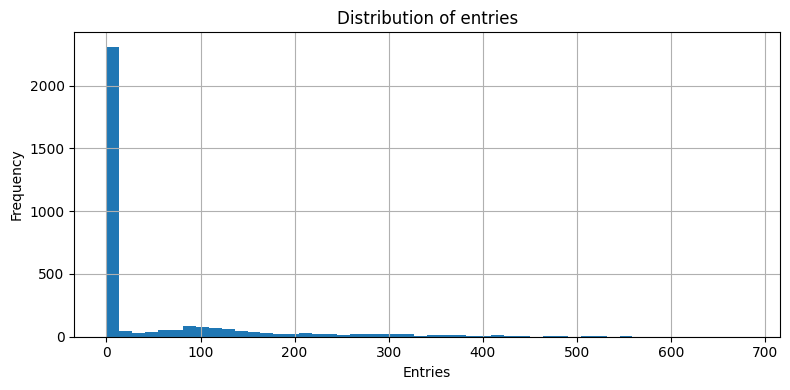

Rows with entries < 10: 2289
Rows with entries < 50: 2405


In [67]:
plt.figure(figsize=(8, 4))
route_daily["entries"].dropna().hist(bins=50)
plt.title("Distribution of entries")
plt.xlabel("Entries")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

route_daily["is_low_volume"] = (route_daily["entries"] < 10).astype(int)
route_daily["is_low_volume_50"] = (route_daily["entries"] < 50).astype(int)
print(f"Rows with entries < 10: {route_daily['is_low_volume'].sum()}")
print(f"Rows with entries < 50: {route_daily['is_low_volume_50'].sum()}")

## 2.8 Final Cleanup and Export

- Case columns are zero-filled (no match = no cases, not missing data)
- Two pct-change columns with >50% missing are dropped

In [68]:
for col in ["case_records", "total_flights", "unique_alarm_reasons", "unique_event_types"]:
    if col in route_daily.columns:
        route_daily[col] = route_daily[col].fillna(0)

route_daily["alarm_density_per_entry"] = np.where(
    route_daily["entries"] > 0, route_daily["case_records"] / route_daily["entries"], np.nan)

route_daily.drop(columns=['flagged_pct_change1', 'flag_rate_pct_change1'], inplace=True, errors='ignore')

full_feature_cols = (ID_COLS + CALENDAR_COLS + BASE_COLS + SEGMENT_COLS + CASE_COLS + CHANGE_COLS + VOLUME_FLAG_COLS)
full_feature_cols = [c for c in full_feature_cols if c in route_daily.columns]

feature_engineered_full = route_daily[full_feature_cols].copy()
feature_engineered_full.to_csv(FEAT_ENGEERING_OUT, index=False)
print(f"Feature-engineered table: {feature_engineered_full.shape}")

Feature-engineered table: (3267, 56)


# 3. Anomaly Detection

This section implements the unsupervised anomaly detection layer.

The dataset does not contain ground-truth anomaly labels. For this reason we do not use a train/test split and we do not report supervised metrics (accuracy, precision, recall, F1, ROC-AUC) — that would only simulate supervised validation without real labels.

Instead, the pipeline performs retrospective unsupervised anomaly scoring on the full cleaned dataset. The objective is to identify observations that deviate from historical traffic behavior and should be prioritized for analyst review. The evaluation focuses on operational criteria: anomaly rate, agreement between detectors, stability under different contamination thresholds, and interpretability of the final ranked alert queue.

In [69]:
df = pd.read_csv(FEAT_ENGEERING_OUT)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["route_airport", "date"]).reset_index(drop=True)
print(f"Loaded {len(df)} rows, {df['route_airport'].nunique()} routes")

Loaded 3267 rows, 514 routes


## 3.1 Historical Baselines

Two types of baselines are computed to define what "normal" looks like for each route:

1. **Rolling averages** (7-obs and 30-obs windows) capture recent trends
2. **Monthly seasonal baselines** capture recurring monthly patterns

We use observation-based windows rather than calendar-based: the dataset is irregular, with median 3-day gaps and some routes having month-long gaps. A calendar-based 7-day window would often contain only 1-2 data points.

In [70]:
rolling_targets = ["entries", "flag_rate", "investigation_rate"]

for col in rolling_targets:
    df[f"{col}_roll7"] = df.groupby("route_airport")[col].transform(
        lambda s: s.rolling(7, min_periods=3).mean())
    df[f"{col}_roll30"] = df.groupby("route_airport")[col].transform(
        lambda s: s.rolling(30, min_periods=7).mean())
    df[f"{col}_dev_ratio7"] = np.where(
        df[f"{col}_roll7"].notna() & (df[f"{col}_roll7"] > 0),
        df[col] / df[f"{col}_roll7"], np.nan)

print(f"Rolling 7-obs coverage: {df['entries_roll7'].notna().mean():.1%}")
print(f"Rolling 30-obs coverage: {df['entries_roll30'].notna().mean():.1%}")

Rolling 7-obs coverage: 75.4%
Rolling 30-obs coverage: 55.4%


### Monthly Seasonal Baselines

Standard `seasonal_decompose` requires regularly-spaced daily data. Our dataset is too irregular for it (median of 2 observations spread over months). Instead, for each `route_airport × month` we compute the average entries as a baseline. The residual is the deviation from this monthly norm, normalized to z-score per route.

A static route-level mean is also computed as a stable reference, especially useful for routes with too few observations to support rolling windows.

In [71]:
df["entries_monthly_baseline"] = df.groupby(["route_airport", "month"])["entries"].transform("mean")
df["entries_residual"] = df["entries"] - df["entries_monthly_baseline"]

residual_std = df.groupby("route_airport")["entries_residual"].transform("std")
df["entries_residual_z"] = np.where(
    residual_std.notna() & (residual_std > 0),
    df["entries_residual"] / residual_std, np.nan)

df["entries_route_mean"] = df.groupby("route_airport")["entries"].transform("mean")
df["entries_vs_route_mean"] = np.where(
    df["entries_route_mean"] > 0,
    df["entries"] / df["entries_route_mean"], np.nan)

print(f"Monthly baseline coverage: {df['entries_monthly_baseline'].notna().mean():.1%}")
print(f"Residual z-score coverage: {df['entries_residual_z'].notna().mean():.1%}")

Monthly baseline coverage: 100.0%
Residual z-score coverage: 79.6%


### Baselines vs Actuals

Sanity-check plot: entries against the 7-observation rolling baseline and monthly residuals for the top 3 routes by traffic.

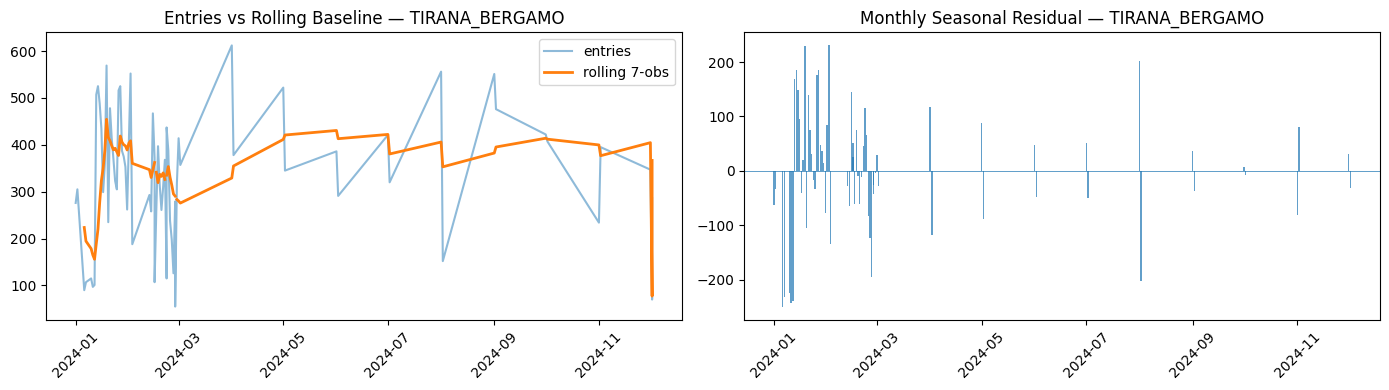

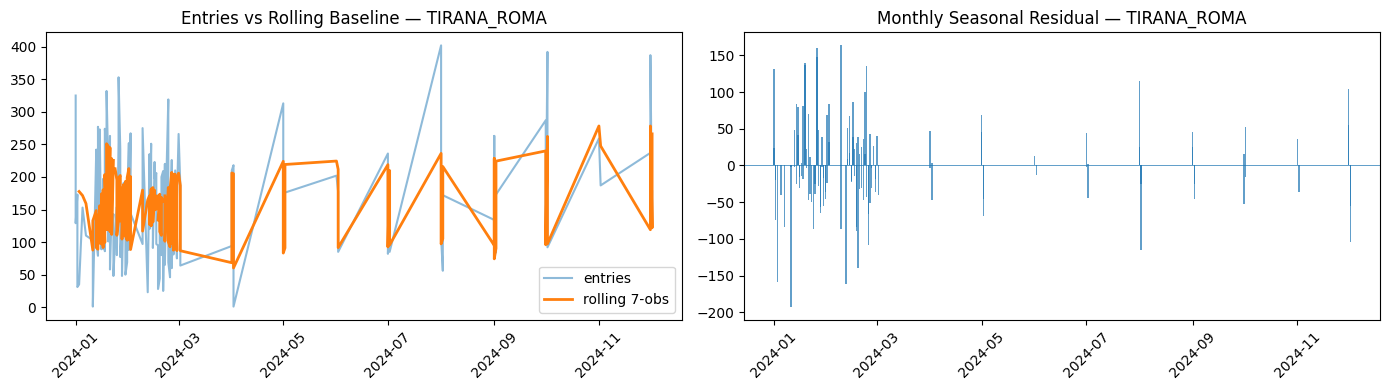

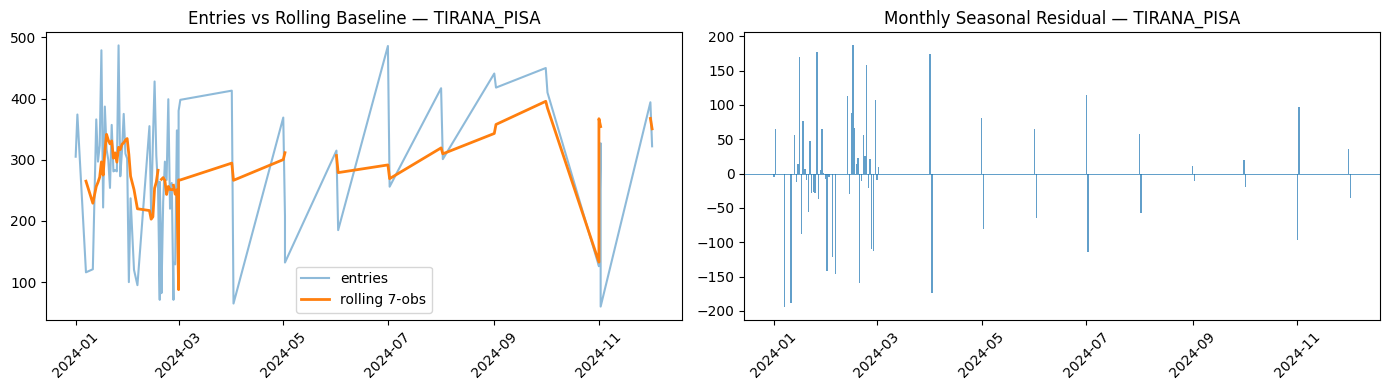

In [72]:
top_routes = (df.groupby("route_city")["entries"]
              .sum().sort_values(ascending=False).head(3).index.tolist())

for route in top_routes:
    tmp = df[df["route_city"] == route].sort_values("date")
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

    axes[0].plot(tmp["date"], tmp["entries"], alpha=0.5, label="entries")
    axes[0].plot(tmp["date"], tmp["entries_roll7"], linewidth=2, label="rolling 7-obs")
    axes[0].set_title(f"Entries vs Rolling Baseline — {route}")
    axes[0].legend()

    axes[1].bar(tmp["date"], tmp["entries_residual"], alpha=0.7)
    axes[1].axhline(0, linewidth=0.5)
    axes[1].set_title(f"Monthly Seasonal Residual — {route}")

    for ax in axes:
        ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

## 3.2 Missing Value Handling

Different column groups have different reasons for missing values:

- **lag/diff/pct_change** (~15-19% missing): the first observation per route has no previous value → fill with 0
- **flag_given_investigated** (~4%): undefined when investigated = 0 → fill with 0
- **rate columns** (~0.1%): undefined when entries = 0 → fill with 0
- **rolling features** (~25%): too few observations → fill with column median
- **seasonal features** (~20%): single-observation months produce undefined std → fill with 0

In [73]:
change_fill = [c for c in df.columns if "_lag1" in c or "_diff1" in c or "_pct_change1" in c]
df[change_fill] = df[change_fill].fillna(0)

df["flag_given_investigated"] = df["flag_given_investigated"].fillna(0)

rate_fill = ["investigation_rate", "flag_rate", "alarm_density_per_entry",
             "avg_nat_flag_rate", "max_nat_flag_rate",
             "avg_doc_flag_rate", "max_doc_flag_rate",
             "avg_airline_flag_rate", "max_airline_flag_rate",
             "avg_control_flag_rate", "max_control_flag_rate"]
df[rate_fill] = df[rate_fill].fillna(0)

rolling_fill = [c for c in df.columns if "_roll" in c or "_dev_ratio" in c]
df[rolling_fill] = df[rolling_fill].fillna(df[rolling_fill].median())

for c in ["entries_residual", "entries_residual_z", "entries_monthly_baseline",
          "entries_route_mean", "entries_vs_route_mean"]:
    df[c] = df[c].fillna(0)

remaining = df.select_dtypes(include=[np.number]).isna().sum()
remaining = remaining[remaining > 0]
print("All numeric columns complete." if len(remaining) == 0 else f"Remaining NaN columns: {len(remaining)}")

All numeric columns complete.


## 3.3 Feature Selection — Detection vs Reporting

We split features into two groups based on their causal role:

- **Detection features** describe traffic behavior and historical deviations. They are observable before any operational intervention.
- **Reporting features** describe the *consequence* of operational decisions (flag rates, investigation outcomes, alarm cases). Using them to detect anomalies would create leakage: an observation may look anomalous *because* it was already investigated and flagged, not because of suspicious traffic.

The detection layer runs only on detection features. Reporting features are added back during post-processing to explain anomalies in operational terms.

In [74]:
DETECTION_FEATURES = [
    "entries",
    "entries_lag1", "entries_diff1", "entries_pct_change1",
    "entries_roll7", "entries_roll30", "entries_dev_ratio7",
    "entries_monthly_baseline", "entries_residual", "entries_residual_z",
    "entries_route_mean", "entries_vs_route_mean",
    "weekday", "is_weekend",
    "is_low_volume", "is_low_volume_50",
]

REPORTING_FEATURES = [
    "investigated", "flagged",
    "investigation_rate", "flag_rate", "flag_given_investigated",
    "has_case_match", "case_records", "total_flights",
    "unique_alarm_reasons", "unique_event_types", "alarm_density_per_entry",
]

feature_cols = [c for c in DETECTION_FEATURES if c in df.columns]
reporting_cols = [c for c in REPORTING_FEATURES if c in df.columns]

print(f"Detection features ({len(feature_cols)}): {feature_cols}")
print(f"Reporting features ({len(reporting_cols)}): {reporting_cols}")

Detection features (16): ['entries', 'entries_lag1', 'entries_diff1', 'entries_pct_change1', 'entries_roll7', 'entries_roll30', 'entries_dev_ratio7', 'entries_monthly_baseline', 'entries_residual', 'entries_residual_z', 'entries_route_mean', 'entries_vs_route_mean', 'weekday', 'is_weekend', 'is_low_volume', 'is_low_volume_50']
Reporting features (11): ['investigated', 'flagged', 'investigation_rate', 'flag_rate', 'flag_given_investigated', 'has_case_match', 'case_records', 'total_flights', 'unique_alarm_reasons', 'unique_event_types', 'alarm_density_per_entry']


## 3.4 Scaling

IsolationForest and LOF are distance-sensitive. Without scaling, features with larger raw values (entries in the hundreds) would dominate features with smaller scales (rates between 0 and 1). We standardize with `StandardScaler` so each detection feature has equal weight a priori.

In [75]:
X = df[feature_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled matrix: {X_scaled.shape}")

Scaled matrix: (3267, 16)


## 3.5 Anomaly Detection — Three Methods

We apply three complementary unsupervised methods, each with `contamination=0.05`:

1. **Isolation Forest** — global multivariate outliers (joint feature space)
2. **Local Outlier Factor** — local density anomalies (neighborhood-based)
3. **Multivariate Z-score** — extreme single-feature deviations (most interpretable)

Fixing the same contamination across methods makes the comparison fair: each model has the same anomaly budget, so the value of consensus voting comes from *which* observations they flag, not *how many*. We tested both fixed and unfixed contamination — without it, the Z-score becomes far more aggressive than the others (33% vs 12%) and the consensus becomes unbalanced.

In [76]:
iso = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
df["iso_label"] = iso.fit_predict(X_scaled)
df["iso_anomaly"] = (df["iso_label"] == -1).astype(int)
df["iso_score"] = iso.decision_function(X_scaled)
print(f"Isolation Forest: {df['iso_anomaly'].sum()} anomalies ({df['iso_anomaly'].mean():.1%})")

Isolation Forest: 164 anomalies (5.0%)


In [77]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df["lof_label"] = lof.fit_predict(X_scaled)
df["lof_anomaly"] = (df["lof_label"] == -1).astype(int)
df["lof_score"] = lof.negative_outlier_factor_
print(f"LOF: {df['lof_anomaly'].sum()} anomalies ({df['lof_anomaly'].mean():.1%})")

LOF: 164 anomalies (5.0%)


In [78]:
df["zscore_max"] = np.abs(X_scaled).max(axis=1)
zscore_threshold = np.percentile(df["zscore_max"], 95)
df["zscore_anomaly"] = (df["zscore_max"] > zscore_threshold).astype(int)
print(f"Z-score: {df['zscore_anomaly'].sum()} anomalies ({df['zscore_anomaly'].mean():.1%})")

Z-score: 164 anomalies (5.0%)


### Consensus Voting

We combine the three models through majority voting: an observation is flagged as a consensus anomaly when at least 2 out of 3 models agree.

In [79]:
df["anomaly_votes"] = df["iso_anomaly"] + df["lof_anomaly"] + df["zscore_anomaly"]
df["consensus_anomaly"] = (df["anomaly_votes"] >= 2).astype(int)
print(f"Consensus anomalies (>=2 votes): {df['consensus_anomaly'].sum()} ({df['consensus_anomaly'].mean():.1%})")

Consensus anomalies (>=2 votes): 108 (3.3%)


### Detector Overlap

The overlap matrix shows pairwise agreement. Partial overlap is expected because each method captures a different anomaly concept. If overlap were near 100% the three models would be redundant; if it were near 0% the consensus would be unreliable.

In [80]:
model_cols = ["iso_anomaly", "lof_anomaly", "zscore_anomaly"]
overlap = pd.DataFrame(index=model_cols, columns=model_cols, dtype=int)
for a in model_cols:
    for b in model_cols:
        overlap.loc[a, b] = int(((df[a] == 1) & (df[b] == 1)).sum())
print("Pairwise overlap (count):")
print(overlap)

Pairwise overlap (count):
                iso_anomaly  lof_anomaly  zscore_anomaly
iso_anomaly           164.0          0.0           108.0
lof_anomaly             0.0        164.0             0.0
zscore_anomaly        108.0          0.0           164.0


### Feature Importance

Feature importance is extracted from the Isolation Forest, the only one of the three methods that exposes a native importance attribute (it is tree-based, so each feature gets a score based on how often and how early it is used to isolate observations). LOF works on distances and Z-score on individual feature thresholds — neither produces a global feature ranking.

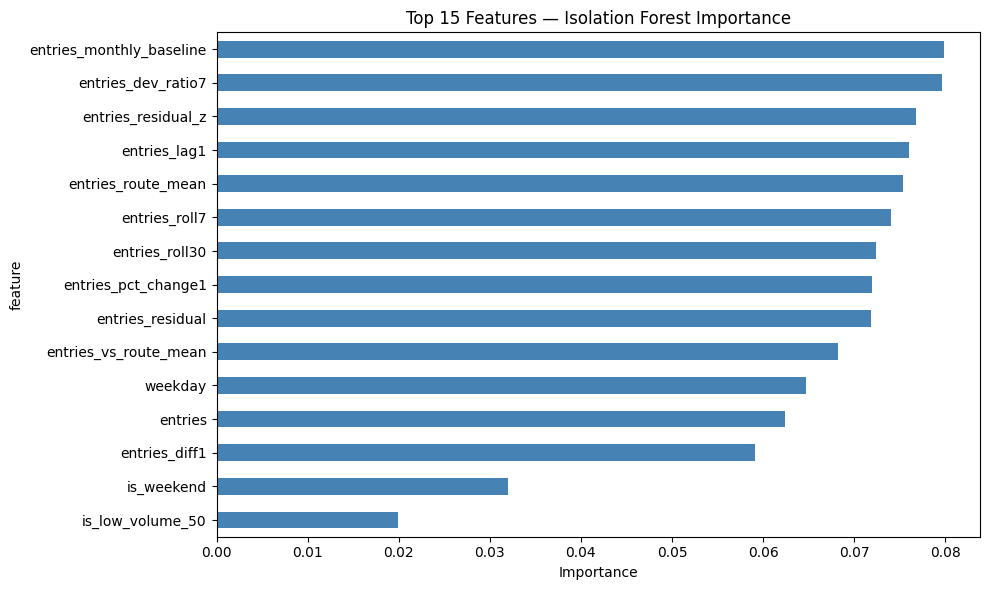

In [81]:
importances = np.zeros(len(feature_cols))
for tree in iso.estimators_:
    importances += tree.feature_importances_
importances /= len(iso.estimators_)

feat_imp = (pd.DataFrame({"feature": feature_cols, "importance": importances})
            .sort_values("importance", ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(15).plot.barh(x="feature", y="importance", ax=ax, legend=False, color="steelblue")
ax.invert_yaxis()
ax.set_title("Top 15 Features — Isolation Forest Importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "classical_feature_importance.png", dpi=150)
plt.show()

## 3.6 Sensitivity Analysis

Without ground-truth labels we cannot measure precision or recall. We can however check whether the system is **stable**: does the consensus flagged set change drastically when we change the contamination threshold? A stable pipeline means that the detection logic doesn't depend on a single arbitrary choice. We re-run the three models for contamination values of 3%, 5%, 7% and 10%.

In [82]:
contamination_grid = [0.03, 0.05, 0.07, 0.10]
sensitivity_results = []

for c in contamination_grid:
    iso_tmp = IsolationForest(contamination=c, random_state=42, n_jobs=-1)
    iso_flag = (iso_tmp.fit_predict(X_scaled) == -1).astype(int)

    lof_tmp = LocalOutlierFactor(n_neighbors=20, contamination=c)
    lof_flag = (lof_tmp.fit_predict(X_scaled) == -1).astype(int)

    z_thresh = np.percentile(np.abs(X_scaled).max(axis=1), 100 * (1 - c))
    z_flag = (np.abs(X_scaled).max(axis=1) > z_thresh).astype(int)

    votes = iso_flag + lof_flag + z_flag
    consensus = (votes >= 2).astype(int)

    sensitivity_results.append({
        "contamination": c,
        "iso_rate": round(iso_flag.mean(), 4),
        "lof_rate": round(lof_flag.mean(), 4),
        "zscore_rate": round(z_flag.mean(), 4),
        "consensus_rate": round(consensus.mean(), 4),
        "consensus_count": int(consensus.sum())
    })

sensitivity_df = pd.DataFrame(sensitivity_results)
sensitivity_df.to_csv(ANOMALY_DIR / "classical_sensitivity.csv", index=False)
print(sensitivity_df.to_string(index=False))

 contamination  iso_rate  lof_rate  zscore_rate  consensus_rate  consensus_count
          0.03    0.0300    0.0272       0.0300          0.0162               53
          0.05    0.0502    0.0502       0.0502          0.0331              108
          0.07    0.0701    0.0701       0.0701          0.0499              163
          0.10    0.1001    0.1001       0.1001          0.0759              248


# 4. Post-Processing

Statistical models flag observations that are statistically unusual. The post-processing layer applies operational business rules on top of model output to highlight observations that match known risk patterns.

Unlike the detection layer, business rules can use reporting features (flag rate, alarm density). They act *after* the detection on observable evidence that an analyst would consider anyway. Their role is operational filtering, not causal inference.

## 4.1 Business Rules

Four rules:

- `flag_rate_dev_ratio7 > 3` → flag rate exceeded 3× recent baseline
- `entries_dev_ratio7 > 3` → passenger volume exceeded 3× recent baseline
- `abs(entries_residual_z) > 2` → entries deviate more than 2σ from monthly norm
- `alarm_density_per_entry > 95th percentile` → disproportionate alarm cases

In [83]:
df["rule_flag_spike"] = (df["flag_rate_dev_ratio7"] > 3).astype(int)
df["rule_entries_spike"] = (df["entries_dev_ratio7"] > 3).astype(int)
df["rule_high_residual_z"] = (df["entries_residual_z"].abs() > 2).astype(int)

alarm_95 = df["alarm_density_per_entry"].quantile(0.95)
df["rule_high_alarm"] = (df["alarm_density_per_entry"] > alarm_95).astype(int)

rule_cols = ["rule_flag_spike", "rule_entries_spike", "rule_high_residual_z", "rule_high_alarm"]
df["rule_count"] = df[rule_cols].sum(axis=1)
df["rule_any"] = (df["rule_count"] > 0).astype(int)
print(f"Rules triggered: {df['rule_any'].sum()} / {len(df)}")

Rules triggered: 383 / 3267


## 4.2 Final Anomaly Label

```
final_anomaly = consensus_anomaly OR rule_any
```

This captures both statistically unusual observations and operationally meaningful patterns. The result is an alert queue for analyst review, not a definitive classification.

In [84]:
df["final_anomaly"] = ((df["consensus_anomaly"] == 1) | (df["rule_any"] == 1)).astype(int)
print(f"Final anomalies: {df['final_anomaly'].sum()} / {len(df)} ({df['final_anomaly'].mean():.1%})")

Final anomalies: 456 / 3267 (14.0%)


## 4.3 Risk Score and Review Priority

The risk score combines model agreement, rule strength, recent traffic spike and seasonal deviation into a single 0-100 operational severity index. It is **not a calibrated probability of threat** — it is a ranking signal for analyst review.

`review_priority` then divides flagged anomalies into actionable tiers (P1 immediate review, P2 high, P3 standard, P4 monitor) using percentile thresholds within the flagged set. This guarantees a usable queue even if absolute scores are moderate.

In [85]:
def robust_score(series, lower_q=0.01, upper_q=0.99):
    s = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
    if s.notna().sum() == 0:
        return pd.Series(0.0, index=s.index)
    lo, hi = s.quantile(lower_q), s.quantile(upper_q)
    if pd.isna(lo) or pd.isna(hi) or hi <= lo:
        return pd.Series(0.0, index=s.index)
    return ((s.clip(lo, hi) - lo) / (hi - lo)).fillna(0.0)

# Clean infinities before scoring
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)

df["model_agreement"] = df[model_cols].sum(axis=1)

components = pd.DataFrame(index=df.index)
components["model_agreement"] = (df["model_agreement"] / len(model_cols)).clip(0, 1)
components["rule_strength"] = (df["rule_count"] / len(rule_cols)).clip(0, 1)
components["entries_spike"] = robust_score(df["entries_dev_ratio7"])
components["seasonal_residual"] = robust_score(df["entries_residual_z"].abs())

weights = {"model_agreement": 0.40, "rule_strength": 0.25, "entries_spike": 0.20, "seasonal_residual": 0.15}
df["risk_score"] = sum(components[c] * w for c, w in weights.items()) * 100
df.loc[df["final_anomaly"] == 0, "risk_score"] *= 0.25
df["risk_score"] = df["risk_score"].round(2)

df["risk_level"] = pd.cut(df["risk_score"], bins=[-0.01, 20, 40, 60, 100],
                          labels=["Low", "Moderate", "High", "Critical"])

df["review_priority"] = "Not flagged"
flagged_mask = df["final_anomaly"] == 1
if flagged_mask.sum() > 0:
    flagged_scores = df.loc[flagged_mask, "risk_score"]
    q50, q80, q95 = flagged_scores.quantile([0.50, 0.80, 0.95])

    def assign_priority(s):
        if s >= q95: return "P1 - immediate review"
        if s >= q80: return "P2 - high priority"
        if s >= q50: return "P3 - standard review"
        return "P4 - monitor"

    df.loc[flagged_mask, "review_priority"] = flagged_scores.apply(assign_priority)

print("Risk-level distribution:")
print(df["risk_level"].value_counts().sort_index())
print("\nReview-priority distribution among final anomalies:")
print(df.loc[flagged_mask, "review_priority"].value_counts())

Risk-level distribution:
risk_level
Low         3023
Moderate     154
High          73
Critical      17
Name: count, dtype: int64

Review-priority distribution among final anomalies:
review_priority
P4 - monitor             228
P3 - standard review     136
P2 - high priority        69
P1 - immediate review     23
Name: count, dtype: int64


## 4.4 Evidence Type and Explanation

Each anomaly is labeled by where the alert came from: model consensus, business rules, or both. This makes the system transparent — Reply or an analyst can see exactly why each observation made the queue.

In [86]:
rule_label_map = {
    "rule_flag_spike": "flag rate above recent baseline",
    "rule_entries_spike": "passenger entries above recent baseline",
    "rule_high_residual_z": "seasonal residual unusually high",
    "rule_high_alarm": "alarm density in top 5%",
}

model_label_map = {
    "iso_anomaly": "Isolation Forest",
    "lof_anomaly": "LOF",
    "zscore_anomaly": "Z-score",
}

def evidence_type(row):
    if row["consensus_anomaly"] == 1 and row["rule_any"] == 1:
        return "Model + rules"
    if row["consensus_anomaly"] == 1:
        return "Model consensus only"
    if row["rule_any"] == 1:
        return "Business rules only"
    return "Not flagged"

def build_explanation(row):
    triggered_models = [label for c, label in model_label_map.items() if row.get(c, 0) == 1]
    triggered_rules = [label for c, label in rule_label_map.items() if row.get(c, 0) == 1]
    parts = []
    if triggered_models:
        parts.append("Models: " + ", ".join(triggered_models))
    if triggered_rules:
        parts.append("Rules: " + "; ".join(triggered_rules))
    return " | ".join(parts) if parts else "Not flagged"

df["evidence_type"] = df.apply(evidence_type, axis=1)
df["anomaly_explanation"] = df.apply(build_explanation, axis=1)
print(df.loc[df["final_anomaly"] == 1, "evidence_type"].value_counts())

evidence_type
Business rules only     348
Model consensus only     73
Model + rules            35
Name: count, dtype: int64


# 5. Ranked Anomaly Report

The main operational deliverable: a sorted alert queue with risk score, review priority, evidence type and human-readable explanation.

In [87]:
anomaly_report = (df.loc[df["final_anomaly"] == 1]
                  .sort_values(["risk_score", "model_agreement", "rule_count"], ascending=False)
                  .reset_index(drop=True))

priority_cols = [
    "risk_score", "risk_level", "review_priority", "evidence_type", "anomaly_explanation",
    "consensus_anomaly", "model_agreement", "rule_any", "rule_count",
    "iso_anomaly", "lof_anomaly", "zscore_anomaly",
    "entries", "investigated", "flagged",
    "investigation_rate", "flag_rate",
    "entries_dev_ratio7", "entries_residual_z",
]
report_cols = [c for c in ["date", "route_airport", "route_city", "route_country"] + priority_cols
               if c in anomaly_report.columns]

print(f"Total final anomalies: {len(anomaly_report)}")
print(f"P1 immediate review: {(anomaly_report['review_priority'] == 'P1 - immediate review').sum()}")
display(anomaly_report[report_cols].head(25))

Total final anomalies: 456
P1 immediate review: 23


,date,route_airport,route_city,route_country,risk_score,risk_level,review_priority,evidence_type,anomaly_explanation,consensus_anomaly,...,iso_anomaly,lof_anomaly,zscore_anomaly,entries,investigated,flagged,investigation_rate,flag_rate,entries_dev_ratio7,entries_residual_z
0,2024-01-18,IST_FCO,ISTANBUL_ROMA,TUR_ITA,74.17,Critical,P1 - immediate review,Model + rules,"Models: Isolation Forest, Z-score | Rules: pas...",1,...,1,0,1,10,10,0,1.000000,0.000000,3.076923,3.147534
1,2024-02-28,JED_FCO,JEDDAH_ROMA,SAU_ITA,74.17,Critical,P1 - immediate review,Model + rules,"Models: Isolation Forest, Z-score | Rules: pas...",1,...,1,0,1,64,0,0,0.000000,0.000000,5.209302,4.495254
2,2024-02-20,KBL_BGY,KABUL_BERGAMO,AFG_ITA,74.17,Critical,P1 - immediate review,Model + rules,"Models: Isolation Forest, Z-score | Rules: pas...",1,...,1,0,1,11,11,2,1.000000,0.181818,3.500000,4.023726
3,2024-01-18,SAW_BGY,ISTANBUL_BERGAMO,TR_ITA,74.17,Critical,P1 - immediate review,Model + rules,"Models: Isolation Forest, Z-score | Rules: pas...",1,...,1,0,1,11,11,2,1.000000,0.181818,3.850000,3.199450
4,2024-02-24,SAW_FCO,ISTANBUL_ROMA,TUR_ITA,74.17,Critical,P1 - immediate review,Model + rules,"Models: Isolation Forest, Z-score | Rules: pas...",1,...,1,0,1,12,12,1,1.000000,0.083333,3.652174,5.138809
5,2024-03-02,TIA_VRN,TIRANA_VERONA,ALB_ITA,74.17,Critical,P1 - immediate review,Model + rules,"Models: Isolation Forest, Z-score | Rules: pas...",1,...,1,0,1,596,594,82,0.996644,0.137584,3.018813,2.985918
6,2024-01-25,IKA_FCO,TEHRAN_ROMA,IRN_ITA,72.11,Critical,P1 - immediate review,Model + rules,"Models: Isolation Forest, Z-score | Rules: pas...",1,...,1,0,1,39,39,0,1.000000,0.000000,4.074627,2.363871
7,2024-02-25,RMF_MXP,MARSA ALAM_MILANO,EG_ITA,71.80,Critical,P1 - immediate review,Model + rules,"Models: Isolation Forest, Z-score | Rules: pas...",1,...,1,0,1,17,16,10,0.941176,0.588235,3.238095,2.306026
8,2024-01-18,PRN_MXP,PRISTINA_MILANO,RKS_ITA,70.71,Critical,P1 - immediate review,Model + rules,"Models: Isolation Forest, Z-score | Rules: fla...",1,...,1,0,1,19,19,1,1.000000,0.052632,2.235294,3.542787
9,2024-01-20,DXB_MXP,DUBAI_MILANO,ARE_ITA,67.92,Critical,P1 - immediate review,Model + rules,"Models: Isolation Forest, Z-score | Rules: sea...",1,...,1,0,1,7,7,2,1.000000,0.285714,3.000000,4.473246


## 5.1 Summary Tables

In [88]:
summary_overall = pd.DataFrame({
    "metric": [
        "total_observations", "final_anomalies", "final_anomaly_rate",
        "model_consensus_anomalies", "business_rule_anomalies", "model_and_rule_overlap",
        "average_risk_score_all_rows", "average_risk_score_anomalies",
    ],
    "value": [
        len(df),
        int(df["final_anomaly"].sum()),
        round(df["final_anomaly"].mean(), 4),
        int(df["consensus_anomaly"].sum()),
        int(df["rule_any"].sum()),
        int(((df["consensus_anomaly"] == 1) & (df["rule_any"] == 1)).sum()),
        round(df["risk_score"].mean(), 2),
        round(df.loc[df["final_anomaly"] == 1, "risk_score"].mean(), 2),
    ]
})

evidence_distribution = (df.loc[df["final_anomaly"] == 1]
    .groupby("evidence_type").size().reset_index(name="anomalies")
    .assign(share=lambda x: (x["anomalies"] / x["anomalies"].sum()).round(3))
    .sort_values("anomalies", ascending=False))

top_groups = (df.groupby("route_city")
    .agg(observations=("final_anomaly", "size"),
         anomalies=("final_anomaly", "sum"),
         avg_risk_score=("risk_score", "mean"),
         max_risk_score=("risk_score", "max"))
    .query("anomalies > 0")
    .sort_values(["anomalies", "max_risk_score"], ascending=False)
    .head(10).reset_index())

display(summary_overall)
display(evidence_distribution)
display(top_groups)

,metric,value
0,total_observations,3267.0000
1,final_anomalies,456.0000
2,final_anomaly_rate,0.1396
3,model_consensus_anomalies,108.0000
4,business_rule_anomalies,383.0000
5,model_and_rule_overlap,35.0000
6,average_risk_score_all_rows,6.0600
7,average_risk_score_anomalies,27.3700


,evidence_type,anomalies,share
0,Business rules only,348,0.763
2,Model consensus only,73,0.160
1,Model + rules,35,0.077


,route_city,observations,anomalies,avg_risk_score,max_risk_score
0,TIRANA_BERGAMO,70,36,22.867714,54.44
1,LONDRA_MILANO,136,32,6.623162,39.82
2,LONDRA_ROMA,90,27,7.713111,54.58
3,LONDRA_BERGAMO,64,24,8.613437,43.41
4,TIRANA_PISA,71,21,14.275352,56.59
5,TIRANA_BOLOGNA,71,17,12.649718,56.18
6,LONDRA_BOLOGNA,70,16,6.298714,47.42
7,LONDRA_VENEZIA,59,14,7.098814,60.83
8,TIRANA_ROMA,125,13,7.515920,65.36
9,LONDRA_TORINO,49,12,7.279388,60.83


## 5.2 Figures

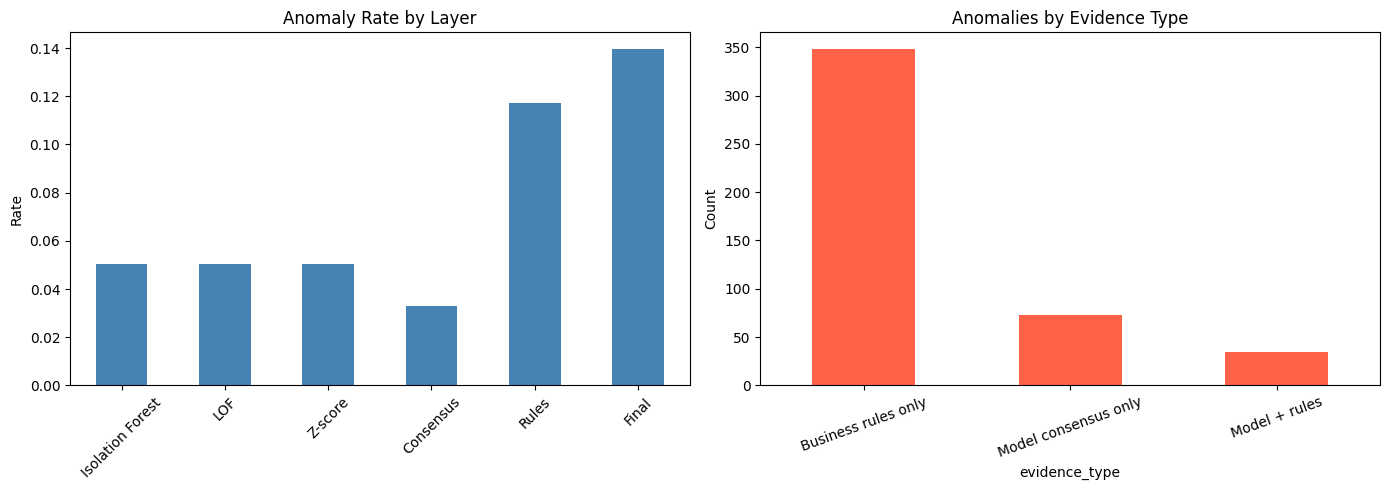

In [89]:
# Anomaly rate by detector
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rates = pd.Series({
    "Isolation Forest": df["iso_anomaly"].mean(),
    "LOF": df["lof_anomaly"].mean(),
    "Z-score": df["zscore_anomaly"].mean(),
    "Consensus": df["consensus_anomaly"].mean(),
    "Rules": df["rule_any"].mean(),
    "Final": df["final_anomaly"].mean(),
})
rates.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Anomaly Rate by Layer")
axes[0].set_ylabel("Rate")
axes[0].tick_params(axis="x", rotation=45)

evidence_distribution.plot(kind="bar", x="evidence_type", y="anomalies", ax=axes[1],
                           legend=False, color="tomato")
axes[1].set_title("Anomalies by Evidence Type")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "classical_anomaly_overview.png", dpi=150)
plt.show()

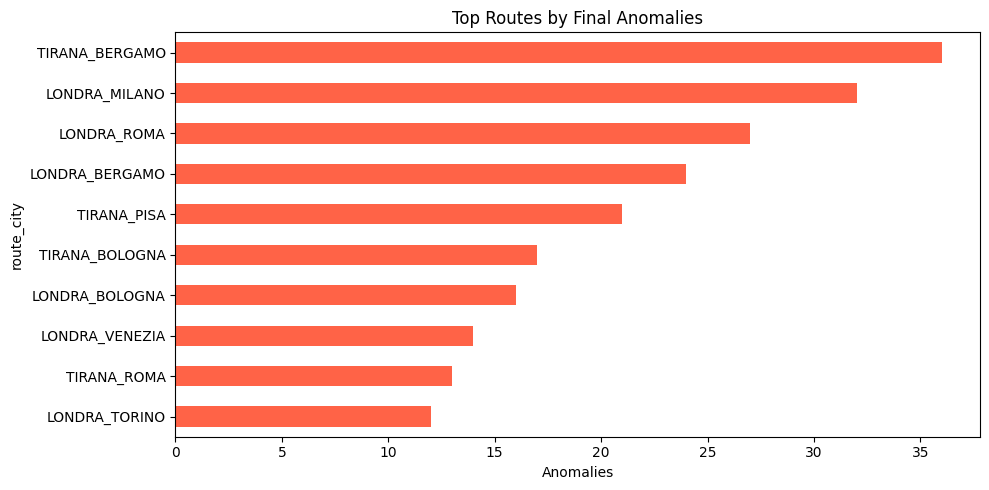

In [90]:
# Top routes by anomaly count
if not top_groups.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    top_groups.sort_values("anomalies").plot(
        kind="barh", x="route_city", y="anomalies", ax=ax, legend=False, color="tomato")
    ax.set_title("Top Routes by Final Anomalies")
    ax.set_xlabel("Anomalies")
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "classical_top_routes.png", dpi=150)
    plt.show()

# 6. Export Final Deliverables

We export three files:

1. The full scored dataset with all detection scores, rules, risk levels and explanations
2. The ranked anomaly report — the operational alert queue sorted by risk score
3. A summary JSON with key metrics for the comparative analysis with the multi-agent pipeline

In [91]:
# Stop the master timer here so the export reflects the true pipeline duration
PIPELINE_END = time.time()
TOTAL_EXEC_TIME = round(PIPELINE_END - PIPELINE_START, 2)
print(f"Total classical pipeline execution time: {TOTAL_EXEC_TIME} seconds")

Total classical pipeline execution time: 3.59 seconds


In [ ]:
full_output_path = REPORT_DIR / "classical_scored_full_dataset.csv"
anomaly_output_path = REPORT_DIR / "classical_ranked_anomaly_report.csv"
markdown_output_path = REPORT_DIR / "classical_transit_anomaly_report.md"
summary_json_path = REPORT_DIR / "classical_summary.json"

df.to_csv(full_output_path, index=False)
anomaly_report[report_cols].to_csv(anomaly_output_path, index=False)

risk_distribution = (
    df.loc[df["final_anomaly"] == 1, "risk_level"]
    .value_counts()
    .reset_index()
)

risk_distribution.columns = ["risk_level", "anomalies"]

priority_distribution = (
    df.loc[df["final_anomaly"] == 1, "review_priority"]
    .value_counts()
    .reset_index()
)

priority_distribution.columns = ["review_priority", "anomalies"]

top_anomalies = anomaly_report.head(10).copy()

top_lines = []

if len(top_anomalies) > 0:
    for rank, (_, row) in enumerate(top_anomalies.iterrows(), start=1):
        identifier = " | ".join([
            f"{c}: {row[c]}"
            for c in ID_COLS
            if c in row.index and pd.notna(row[c])
        ])

        top_lines.append(
            f"{rank}. **{row['review_priority']} — score {row['risk_score']:.2f} ({row['risk_level']})**"
            + (f" — {identifier}" if identifier else "")
            + f" — {row['evidence_type']}: {row['anomaly_explanation']}"
        )
else:
    top_lines.append("No final anomalies were detected.")


summary = {
    "pipeline": "classical",
    "execution_time_seconds": TOTAL_EXEC_TIME if "TOTAL_EXEC_TIME" in globals() else None,
    "total_observations": len(df),
    "iso_anomalies": int(df["iso_anomaly"].sum()),
    "lof_anomalies": int(df["lof_anomaly"].sum()),
    "zscore_anomalies": int(df["zscore_anomaly"].sum()),
    "consensus_anomalies": int(df["consensus_anomaly"].sum()),
    "rule_anomalies": int(df["rule_any"].sum()),
    "final_anomalies": int(df["final_anomaly"].sum()),
    "final_anomaly_rate": round(df["final_anomaly"].mean(), 4),
    "evidence_breakdown": (
        df.loc[df["final_anomaly"] == 1, "evidence_type"]
        .value_counts()
        .to_dict()
    ),
    "risk_level_breakdown": (
        df.loc[df["final_anomaly"] == 1, "risk_level"]
        .value_counts()
        .to_dict()
    ),
    "review_priority_breakdown": (
        df.loc[df["final_anomaly"] == 1, "review_priority"]
        .value_counts()
        .to_dict()
    ),
}

with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, default=str)


markdown_report = f"""# Classical Transit Anomaly Report

## Executive Summary

The classical anomaly detection pipeline processed **{len(df):,} observations** and flagged **{int(df['final_anomaly'].sum()):,} final anomalies**, corresponding to a final anomaly rate of **{df['final_anomaly'].mean():.2%}**.

This report should be interpreted as an **alert-prioritization output**, not as a supervised accuracy evaluation. No ground-truth anomaly labels are available, so precision, recall, F1-score, and ROC-AUC cannot be estimated reliably at this stage.

The final anomaly flag combines two evidence sources:

1. **Model consensus**: at least two classical detectors agree.
2. **Business-rule evidence**: operational thresholds identify unusual traffic spikes or deviations from historical baselines.

Alarm-related and investigation-related indicators are used as contextual evidence in the explanation layer, rather than as supervised labels.

## Main Metrics

{summary_overall.to_markdown(index=False)}

## Risk-Level Distribution Among Final Anomalies

{risk_distribution.to_markdown(index=False) if not risk_distribution.empty else "No final anomalies were detected."}

## Review-Priority Distribution Among Final Anomalies

{priority_distribution.to_markdown(index=False) if not priority_distribution.empty else "No final anomalies were detected."}

## Evidence-Type Distribution Among Final Anomalies

{evidence_distribution.to_markdown(index=False) if not evidence_distribution.empty else "No final anomalies were detected."}

## Top Anomalous Groups

{top_groups.to_markdown(index=False) if not top_groups.empty else "No group-level summary available."}

## Top 10 Ranked Anomalies

{chr(10).join(top_lines)}

## Interpretation

The ranked output should be used as an investigation queue. `P1 - immediate review` cases are the most unusual flagged records relative to the rest of the anomaly set. `P2` and `P3` cases remain relevant but require more contextual validation. `P4` cases are lower-priority alerts that may be useful for monitoring recurring patterns.

A high number of **Business rules only** cases means the final alert volume is strongly influenced by operational thresholds. This is useful for recall, but it may also increase false positives. The next improvement should therefore tune rule thresholds and validate the top-ranked anomalies using proxy labels or expert review.

## Methodological Note

Because the task is unsupervised and no ground-truth labels are available, the classical pipeline does not use a conventional train/test split. Instead, it performs retrospective anomaly scoring over the full cleaned dataset.

The risk score is not a calibrated probability of threat. It is a severity index used to rank alerts for analyst review.

## Files Generated

- `classical_scored_full_dataset.csv`
- `classical_ranked_anomaly_report.csv`
- `classical_summary.json`
- `classical_transit_anomaly_report.md`
- figures saved under `images/`
"""

markdown_output_path.write_text(markdown_report, encoding="utf-8")

print("Export completed.")
print(f"Full scored dataset: {full_output_path}")
print(f"Ranked anomaly report: {anomaly_output_path}")
print(f"Summary JSON: {summary_json_path}")
print(f"Markdown report: {markdown_output_path}")

Export completed.
Full scored dataset: c:\Progetti DS\reply-classical-vs-multiagent\src\io\classical_report\classical_scored_full_dataset.csv
Ranked anomaly report: c:\Progetti DS\reply-classical-vs-multiagent\src\io\classical_report\classical_ranked_anomaly_report.csv
Summary JSON: c:\Progetti DS\reply-classical-vs-multiagent\src\io\classical_report\classical_summary.json
Markdown report: c:\Progetti DS\reply-classical-vs-multiagent\src\io\classical_report\classical_transit_anomaly_report.md


: 